# Deconvolution of Spatial Wavelet Coefficient Representation of Chromatin Images
February 15, 2024

A notebook to test the idea of whether we can deconvolve wavelet coefficients of the chromatin image data.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [204]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [364]:
chromatin_model.create_deconvolution_bins(smoothing=False)

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [365]:
from src.chromatin_wavelets import ChromatinWavelets

chrom_wavelets = ChromatinWavelets(chromatin_model)

In [366]:
chrom_wavelets.create_coefficients()

Created coefficients matrix of shape: (16, 4, 12, 29)
Created coefficients vectorized matrix of shape: (16, 1392)


In [367]:
recon_coefficients_mat = chrom_wavelets.convert_vectorized_coeffs_to_mat(chrom_wavelets.coeffs_vec)


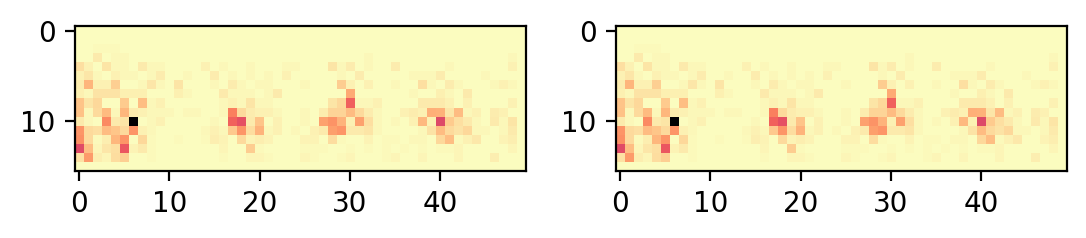

In [368]:
imgs = chrom_wavelets.reconstruct_images(recon_coefficients_mat)
imgs[imgs < 0] = 0

plt.subplot(1, 2, 1)
plt.imshow(chromatin_model.deconv_hist_unflattened[0], cmap='magma_r')

plt.subplot(1, 2, 2)
plt.imshow(imgs[0], cmap='magma_r')


In [294]:
# Now, can we deconvolve the coefficients vector?
chromatin_model.setup_deconv_model()
deconv_model = chromatin_model.deconv_model

In [369]:
G = chrom_wavelets.coeffs_vec

In [370]:

# Threshold G, such that there are non negative values
# This effectively compresses the coefficient matrix
# and removes negative values from G which would cause issues with the solver.
G = chrom_wavelets.coeffs_vec.copy()


0

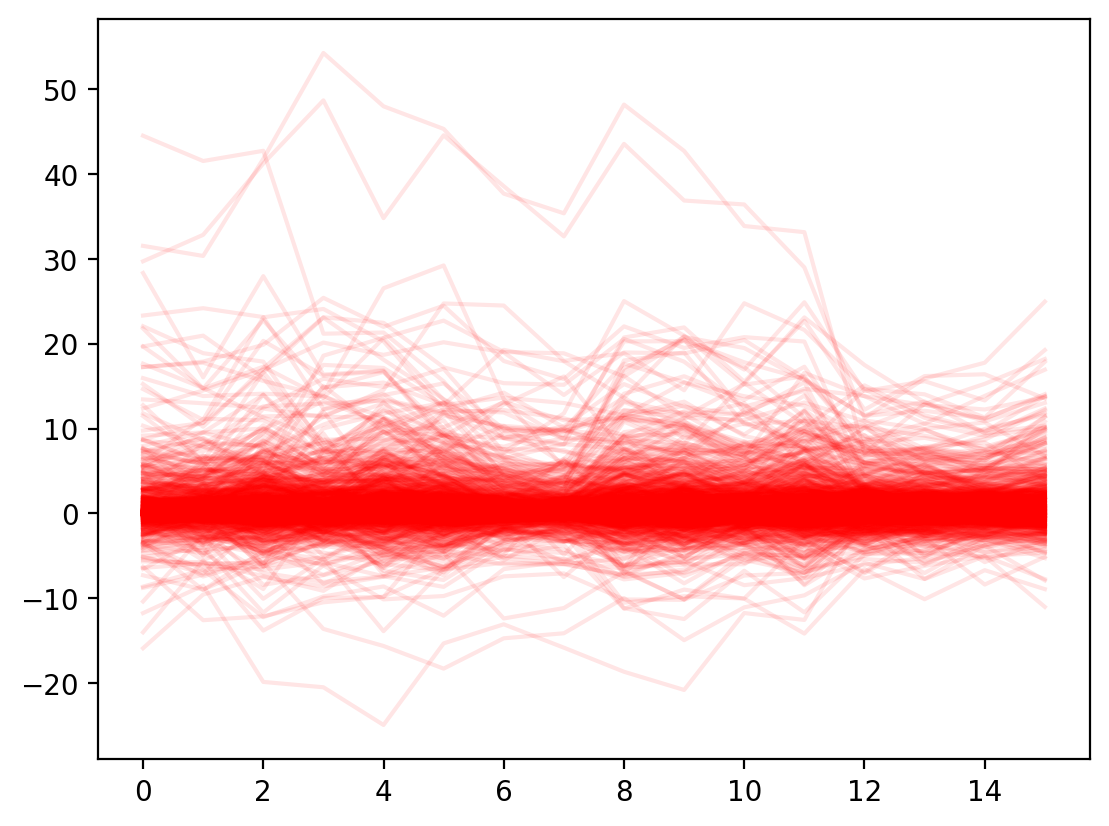

In [371]:
plt.plot(G[:, :], c='red', alpha=0.1)
0

0

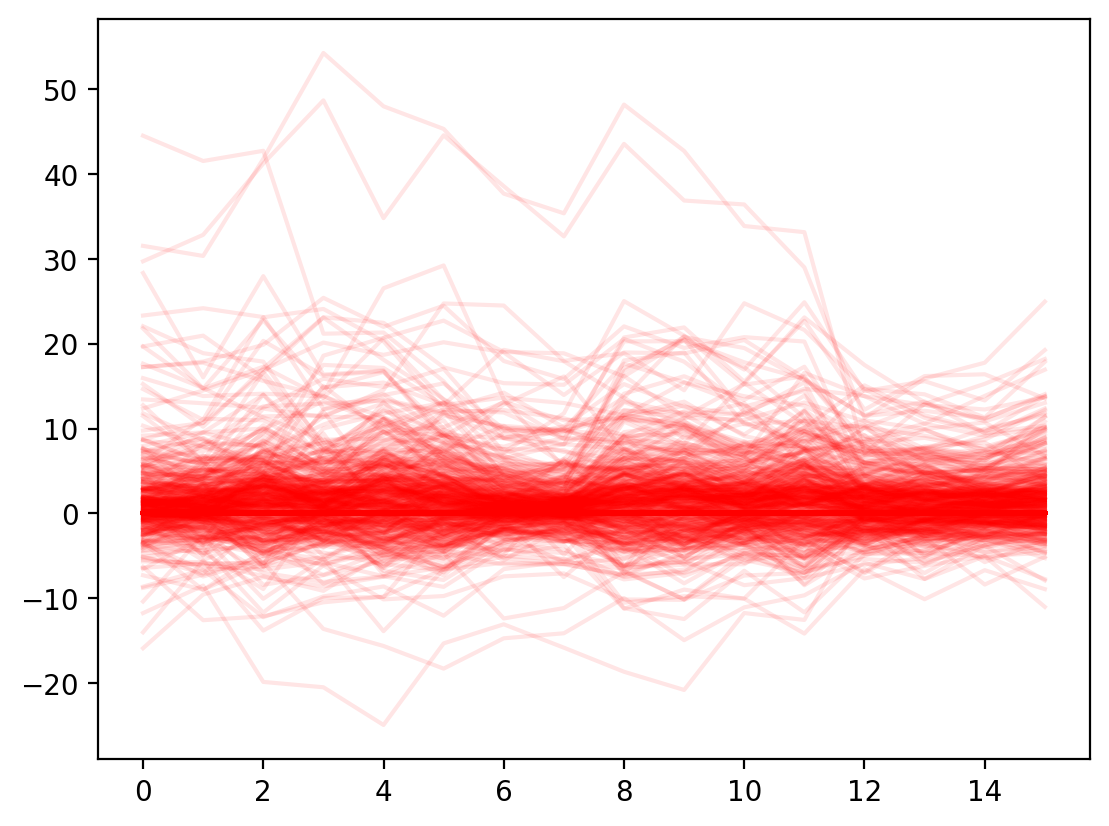

In [372]:
# Enforce that the coefficient must have some value at any timepoint above abs 3
G_thresholded = G.copy()
G_thresholded[:, np.abs(G_thresholded).max(axis=0) < 3] = 0
plt.plot(G_thresholded, c='red', alpha=0.1)
0

In [373]:
from src.deconvolve_chromatin import deconvolve_chromatin_H

chromatin_model.gamma = 1e-2
deconv_model.gamma = 1e-2
f, rn, sn = deconvolve_chromatin_H(deconv_model, deconv_model.H, G_thresholded, verbose=True,
                                  allow_negative=True)


                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 15 01:25:33 PM: Your problem has 315984 variables, 0 constraints, and 0 parameters.
(CVXPY) Feb 15 01:25:33 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 15 01:25:33 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 15 01:25:33 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 15 01:25:33 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 15 01:25:33 PM: Compiling problem (target solver=MOSEK).

(CVXPY) Feb 15 01:28:13 PM: 26  1.4e-02  2.7e-02  1.7e-03  4.99e-01   3.744767693e+03   3.744773364e+03   1.4e-02  62.70 
(CVXPY) Feb 15 01:28:14 PM: 27  1.2e-02  2.3e-02  1.4e-03  4.89e-01   3.702146033e+03   3.702151132e+03   1.2e-02  63.26 
(CVXPY) Feb 15 01:28:14 PM: 28  9.7e-03  1.9e-02  1.1e-03  4.83e-01   3.659808895e+03   3.659813470e+03   9.7e-03  63.83 
(CVXPY) Feb 15 01:28:15 PM: 29  8.4e-03  1.7e-02  9.1e-04  4.76e-01   3.625021577e+03   3.625025760e+03   8.4e-03  64.38 
(CVXPY) Feb 15 01:28:16 PM: 30  7.5e-03  1.5e-02  7.9e-04  4.67e-01   3.598475034e+03   3.598478939e+03   7.5e-03  65.00 
(CVXPY) Feb 15 01:28:16 PM: 31  6.6e-03  1.3e-02  6.6e-04  4.60e-01   3.567533822e+03   3.567537419e+03   6.6e-03  65.58 
(CVXPY) Feb 15 01:28:17 PM: 32  5.4e-03  1.1e-02  5.1e-04  4.57e-01   3.521226333e+03   3.521229500e+03   5.4e-03  66.22 
(CVXPY) Feb 15 01:28:18 PM: 33  5.1e-03  1.0e-02  4.8e-04  4.60e-01   3.510007899e+03   3.510010969e+03   5.1e-03  66.94 
(CVXPY) Feb 15 01:28:18 

In [374]:
f_coeffs_mats = chrom_wavelets.convert_vectorized_coeffs_to_mat(f)
f_imgs = chrom_wavelets.reconstruct_images(f_coeffs_mats)
origin_coeffs_mat = chrom_wavelets.coefficients_matrix

In [375]:
imgs = chrom_wavelets.reconstruct_images(f_coeffs_mats)
imgs.shape

(227, 16, 50)

In [376]:
pred_G_vec = np.matmul(deconv_model.H, f)
pred_G_coeffs_mats = chrom_wavelets.convert_vectorized_coeffs_to_mat(pred_G_vec)
pred_G_imgs = chrom_wavelets.reconstruct_images(pred_G_coeffs_mats)

test_coeffs = chrom_wavelets.coefficients_matrix
G_imgs = chrom_wavelets.reconstruct_images(test_coeffs)

plt_imgs = pred_G_imgs.copy()
plt_imgs[plt_imgs < 0] = 0

G_imgs[G_imgs < 0] = 0

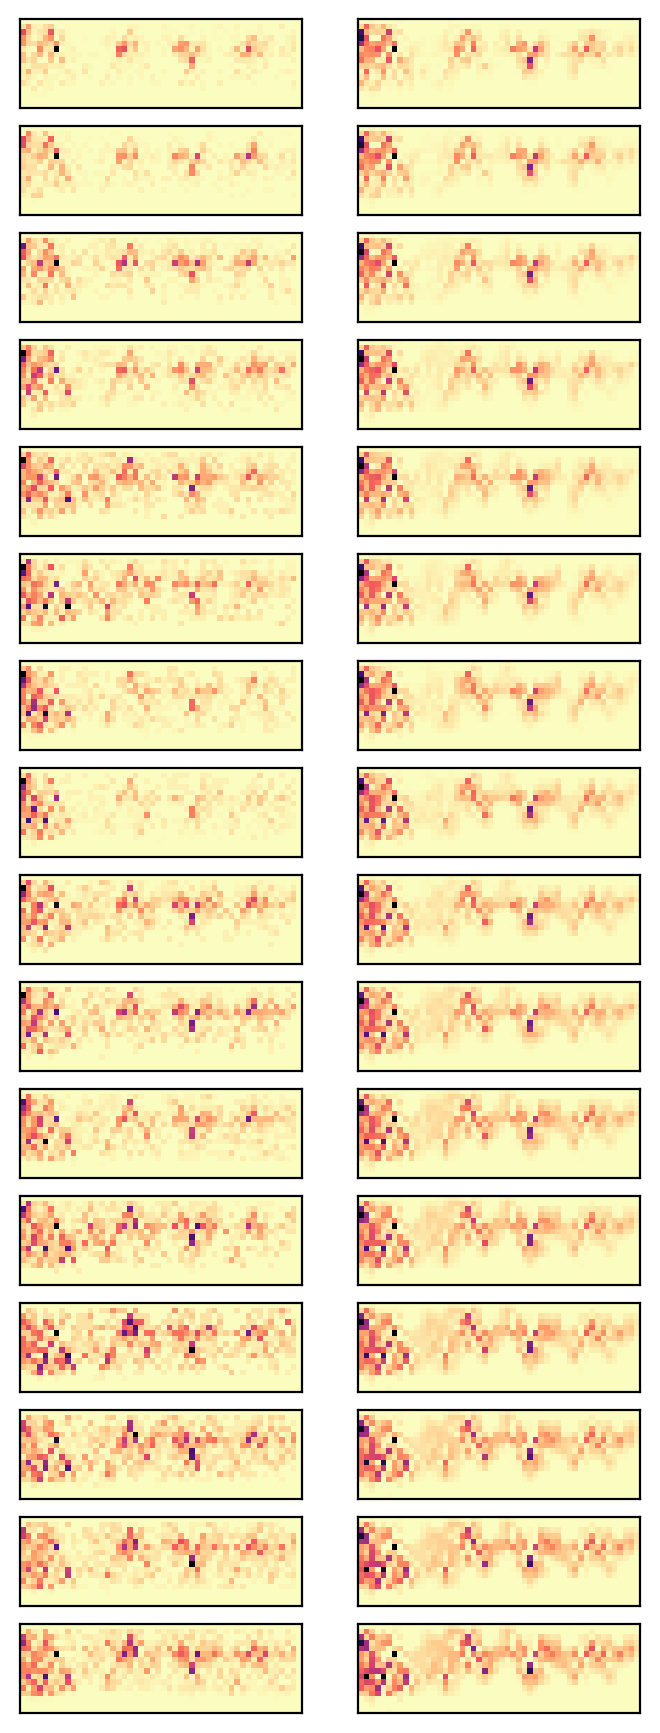

In [377]:
n = G_imgs.shape[0]

plt.figure(figsize=(4, 11))
for i in range(n):

    plt.subplot(n, 2, 2*i+1)
    plt.imshow(G_imgs[i], cmap='magma_r', origin='lower', aspect='auto')
    plt.xticks([])
    plt.yticks([])
    plt.subplot(n, 2, 2*i+2)
    plt.imshow(plt_imgs[i], cmap='magma_r', origin='lower', aspect='auto')
    plt.xticks([])
    plt.yticks([])


0

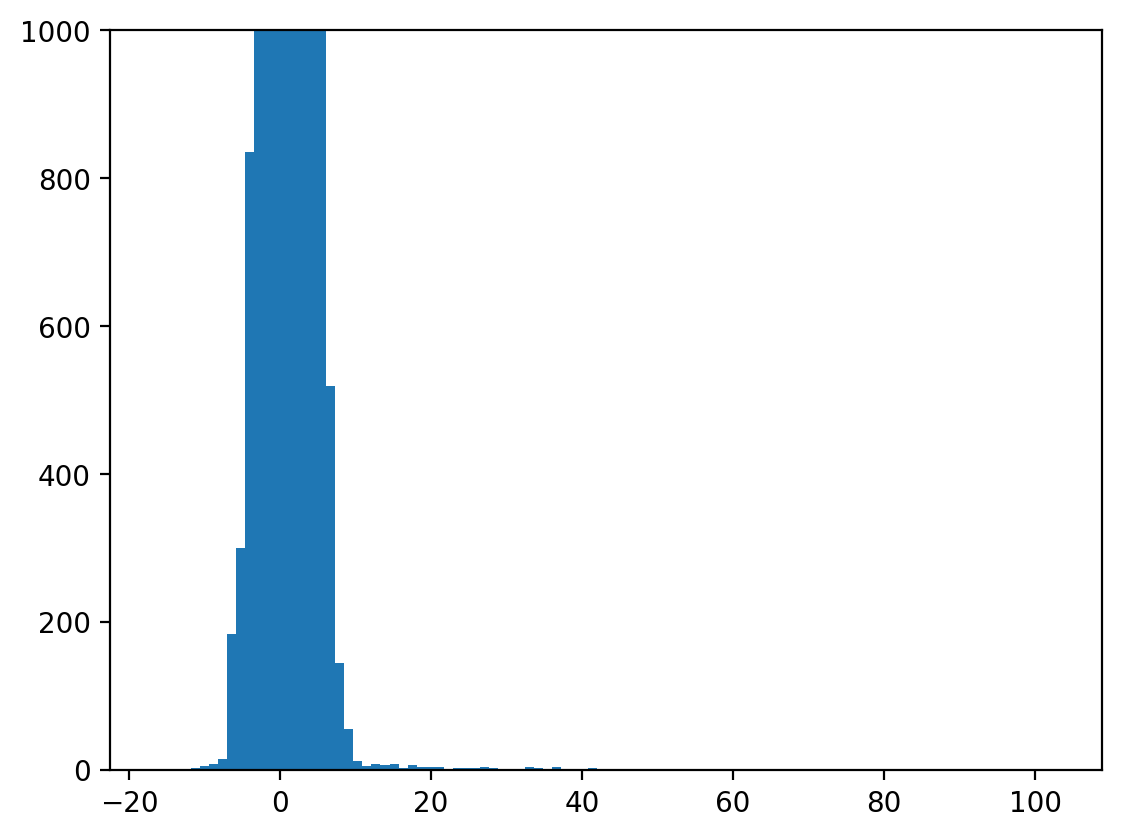

In [399]:
plt.hist(f_imgs.flatten(), bins=100)
plt.ylim(0, 1000)
0

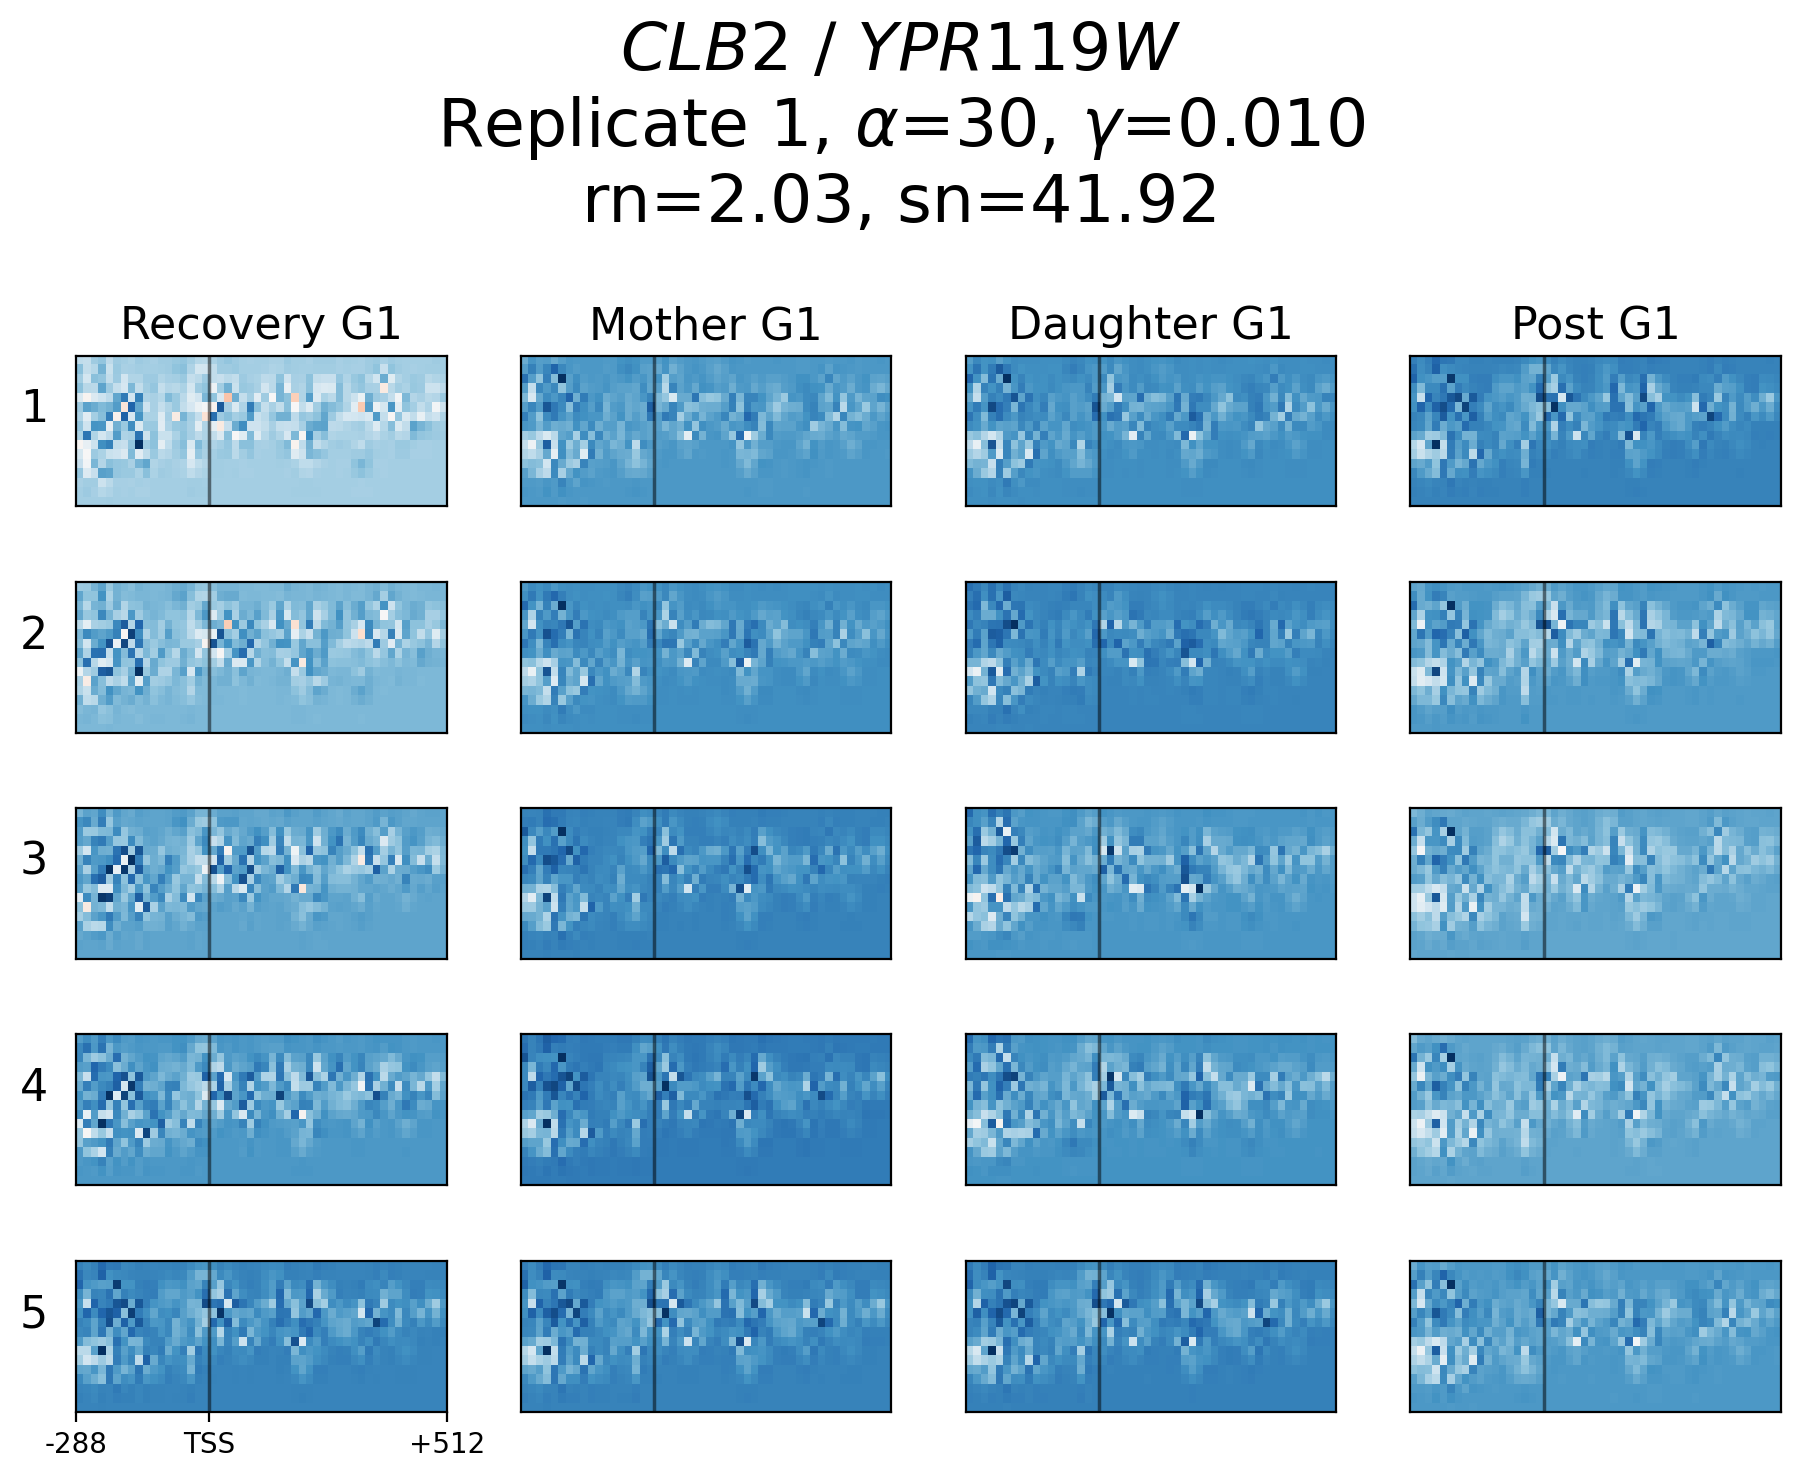

In [401]:
f_imgs_plt = f_imgs.copy()
#f_imgs_plt[f_imgs_plt < 0] = np.abs(f_imgs_plt[f_imgs_plt < 0])
chromatin_model.f = f_imgs_plt

fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(vmin=-20, vmax=20)